# Импортируем нужные библиотеки

In [ ]:
import warnings
import matplotlib.pyplot as plt
from torchvision import transforms as T
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import DataLoader, random_split, Dataset
from tqdm import tqdm
from IPython.display import clear_output
from sklearn.metrics import f1_score, roc_auc_score
import torch.nn.functional as F
import cv2
import albumentations as A
from torch.utils.data import WeightedRandomSampler
import seaborn as sns
import torch.nn as nn
import torchvision.transforms.v2 as T, datasets
from PIL import Image
from torch.optim import Optimizer
from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rc('font', size=30)

*Веса*

In [ ]:
def compute_class_weights(train_labels, device):
    """
    Считает веса классов автоматически из разметки.
    Формула: вес_класса = кол-во_примеров_другого_класса / кол-во_своих
    Это честно и не зависит от ручного подбора.

    Args:
        train_labels: список меток (0 или 1) тренировочного сплита
        device: cuda или cpu

    Returns:
        torch.Tensor с весами [вес_класса_0, вес_класса_1]
    """
    class_counts = np.bincount(train_labels)
    print(f"Распределение классов: 0={class_counts[0]}, 1={class_counts[1]}")

    total = sum(class_counts)
    # обратная частота: редкий класс получает больший вес
    weights = torch.tensor(
        [total / (2 * class_counts[0]),
         total / (2 * class_counts[1])],
        dtype=torch.float
    ).to(device)

    print(f"Веса классов: 0={weights[0]:.3f}, 1={weights[1]:.3f}")
    return weights

# Классы


*Загрузчик тренировочных данных*

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{int(row.iloc[0])}.jpg"
        label = int(row.iloc[1])
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

*Аугментации под гауссовский шум*

In [ ]:
def get_train_transform():
    """
    Аугментации специально подобраны под задачу:
    - CoarseDropout имитирует закрытые пиксели (чёрные и белые)
    - GaussNoise добавляет устойчивость к шуму камеры
    - Геометрические: только горизонтальный флип (вертикальный вреден для лиц)
    - Поворот не более 15° — сохраняет структуру лица
    """
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    return A.Compose([
        A.Resize(256, 256),

        # имитируем чёрные закрытые пиксели
        A.CoarseDropout(
            max_holes=30,
            max_height=20,
            max_width=20,
            min_holes=5,
            fill_value=0,
            p=0.5
        ),
        # имитируем белые закрытые пиксели
        A.CoarseDropout(
            max_holes=30,
            max_height=20,
            max_width=20,
            min_holes=5,
            fill_value=255,
            p=0.5
        ),

        # A.GaussNoise(var_limit=(10, 50), p=0.3),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.4),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        ),

        ToTensorV2()
    ])


def get_val_transform():
    """Валидация - только resize"""
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    return A.Compose([
        A.Resize(256, 256),
        ToTensorV2()
    ])

*Загрузчик тестовых данных*


---
- Тестовые данные не имеют меток — возвращаем только изображение
- Нужно сопоставить предсказание с ID файла для submission
- Имена файлов — это ключ в таблице результатов
- Нужен чтобы правильно сформировать submission.csv

In [ ]:
class KaggleTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = os.listdir(root_dir)

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

*Нормализация*

In [ ]:
class NormalizationLayer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', mean.view(1, 3, 1, 1))
        self.register_buffer('std', std.view(1, 3, 1, 1))

    def forward(self, x):
        # нормализуем только RGB каналы (первые 3)
        rgb = x[:, :3]
        rest = x[:, 3:]
        normalized_rgb = (rgb - self.mean) / (self.std + 1e-8)
        return torch.cat([normalized_rgb, rest], dim=1)

*Свёрточный блок для модели*


---

В этом блокноте работаем только с лучшей полученной моделью, на данный момент model_3_v2

In [ ]:
class ConvBlock_2(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.2):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(dropout_rate)

    def forward(self, x):
        x = self.pool(F.relu(self.bn(self.conv(x))))
        x = self.dropout(x)
        return x


*Основная архитектура*


---
По сравнению с прошлой, беря во внимания GAN структуру нейронки, создавшей дс:
- Увеличен Dropout в fc-слоях (0.5 вместо 0.4)
- Добавлен промежуточный fc2 слой (уменьшает переобучение)
- in_channels=3 по умолчанию, меняй на 6 если используешь FFT-каналы



Это наша прошлая модель, которая хорошо себя показала

In [ ]:
class model_2_optimized(nn.Module):

    def __init__(self, mean, std, in_channels=3):
        super().__init__()
        self.normalize = NormalizationLayer(mean, std)

        self.block1 = ConvBlock_2(in_channels, 8,  dropout_rate=0.2)
        self.block2 = ConvBlock_2(8,  16, dropout_rate=0.2)
        self.block3 = ConvBlock_2(16, 32, dropout_rate=0.3)
        self.block4 = ConvBlock_2(32, 64, dropout_rate=0.3)

        # 256x256 → block1 → 128 → block2 → 64 → block3 → 32 → block4 → 16
        # 64 * 16 * 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.dropout1 = nn.Dropout(0.5)   # с 0.4 до 0.5

        self.fc2 = nn.Linear(512, 128)    # новый промежуточный слой
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.normalize(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)

        x = F.relu(self.fc2(x))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

### Модель model_2_optimized у нас на 8м параметров, поэтому model_3_v2 более лёгкая и эффективная, на 400к параметров. Обучение,  инференс быстрее. Более сильная регуляризация, добавлен GlobalAveragePooling, он усредняет каналы и выстраивает пиксели в один ряд, делая меньшую размерность.

In [ ]:
class model_3_v2(nn.Module):
    """
    Больше каналов (32→64→128→256) + GlobalAveragePooling вместо Flatten.
    GAP схлопывает 256*16*16 → 256, FC становится маленьким и быстрым.
    Всё остальное идентично model_2_optimized.
    """
    def __init__(self, mean, std):
        super().__init__()
        self.normalize = NormalizationLayer(mean, std)

        self.block1 = ConvBlock_2(3,   32,  dropout_rate=0.2)
        self.block2 = ConvBlock_2(32,  64,  dropout_rate=0.2)
        self.block3 = ConvBlock_2(64,  128, dropout_rate=0.3)
        self.block4 = ConvBlock_2(128, 256, dropout_rate=0.3)

        self.gap = nn.AdaptiveAvgPool2d(1)  # 256×16×16 → 256×1×1

        self.fc1      = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2      = nn.Linear(128, 2)

    def forward(self, x):
        x = self.normalize(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)  # (B, 256)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)

        x = self.fc2(x)
        return x

*Класс для обучения с Early Stopping*


---


**Класс ниже предназначе для тренировки моделей с выводом графиков по эпохам. Он написан под метрику f1.**

In [ ]:
class ModelTrainer:
    """
    Тренер с поддержкой Early Stopping по любой метрике (loss, f1, auc)

    Основные возможности:
    ---------------------
    1. Early Stopping по любой метрике (loss, F1, ROC-AUC)
    2. Автоматическое сохранение лучшей модели на каждой эпохе улучшения
    3. Восстановление весов лучшей модели после завершения обучения
    4. Сглаживание волатильных метрик (F1, AUC) для более стабильного Early Stopping
    5. Поддержка Learning Rate Schedulers (особенно ReduceLROnPlateau)
    6. Сохранение модели на Google Drive (опционально)
    7. Визуализация процесса обучения в реальном времени
    8. Поиск оптимального порога классификации для максимизации F1
    """

    def __init__(self, model, optimizer, criterion, device,
                 scheduler=None, patience=5,
                 save_path='best_model.pth',
                 metric_mode='f1',  # 'loss', 'f1', 'auc'
                 smoothing_window=3,
                 save_to_drive=True):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.scheduler = scheduler
        self.patience = patience
        self.save_path = save_path
        self.metric_mode = metric_mode
        self.smoothing_window = smoothing_window
        self.save_to_drive = save_to_drive

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_f1': [],
            'val_auc': []
        }

        # Early Stopping состояние
        if metric_mode in ['f1', 'auc']:
            self.best_metric = -float('inf')
            self.metric_direction = 'max'
        else:
            self.best_metric = float('inf')
            self.metric_direction = 'min'

        self.no_improve_count = 0
        self.best_epoch = 0
        self.smoothed_metrics = []

    def run_epoch(self, dataloader, is_train=True):
        self.model.train(is_train)
        total_loss = 0.0
        all_targets = []
        all_probs = []
        all_preds = []

        with torch.set_grad_enabled(is_train):
            for x, y in tqdm(dataloader, desc='Train' if is_train else 'Val'):
                x, y = x.to(self.device), y.to(self.device)

                outputs = self.model(x)
                loss = self.criterion(outputs, y)

                if is_train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                total_loss += loss.item() * x.size(0)

                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = torch.argmax(outputs, dim=1)

                all_probs.extend(probs.detach().cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        epoch_loss = total_loss / len(dataloader.dataset)
        epoch_f1 = f1_score(all_targets, all_preds, pos_label=1, average='binary', zero_division=0)
        epoch_auc = roc_auc_score(all_targets, all_probs)

        return epoch_loss, epoch_f1, epoch_auc

    def _get_smoothed_metric(self, metric_value):
        """Сглаживание метрики"""
        self.smoothed_metrics.append(metric_value)
        if len(self.smoothed_metrics) > self.smoothing_window:
            self.smoothed_metrics.pop(0)

        if len(self.smoothed_metrics) >= self.smoothing_window:
            return np.mean(self.smoothed_metrics)
        return metric_value

    def train(self, train_loader, val_loader, num_epochs):
        for e in range(num_epochs):
            print(f"\nEpoch {e+1}/{num_epochs}")

            train_loss, _, _ = self.run_epoch(train_loader, is_train=True)
            val_loss, val_f1, val_auc = self.run_epoch(val_loader, is_train=False)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_f1'].append(val_f1)
            self.history['val_auc'].append(val_auc)

            if self.scheduler is not None:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_loss)
                else:
                    self.scheduler.step()
                current_lr = self.optimizer.param_groups[0]['lr']
                print(f"   lr = {current_lr:.6f}")

            # Получаем текущую метрику
            if self.metric_mode == 'f1':
                current_metric = val_f1
            elif self.metric_mode == 'auc':
                current_metric = val_auc
            else:
                current_metric = val_loss

            # Сглаживание для волатильных метрик
            if self.metric_mode in ['f1', 'auc']:
                smoothed = self._get_smoothed_metric(current_metric)
                if self.metric_direction == 'max':
                    is_better = smoothed > self.best_metric
                else:
                    is_better = smoothed < self.best_metric
            else:
                is_better = current_metric < self.best_metric

            print(f"   train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f}")

            # Early Stopping
            if is_better:
                if self.metric_mode in ['f1', 'auc']:
                    self.best_metric = smoothed
                else:
                    self.best_metric = current_metric

                self.no_improve_count = 0
                self.best_epoch = e + 1

                torch.save(self.model.state_dict(), self.save_path)
                print(f"   [SAVED] Лучший {self.metric_mode}={current_metric:.4f} на эпохе {e+1}")

                if self.save_to_drive:
                    try:
                        drive_path = f"/content/drive/MyDrive/{self.save_path}"
                        torch.save(self.model.state_dict(), drive_path)
                    except:
                        pass
            else:
                self.no_improve_count += 1
                print(f"   [NO IMPROVE] {self.no_improve_count}/{self.patience} (лучший был на эпохе {self.best_epoch})")

                if self.no_improve_count >= self.patience:
                    print(f"\nEarly Stopping! Остановлено на эпохе {e+1}")
                    break

            clear_output(wait=True)
            self.plot_history()

        # Загружаем лучшие веса
        self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))
        print(f"\nЗагружены лучшие веса с эпохи {self.best_epoch} (лучший {self.metric_mode}={self.best_metric:.4f})")

    def plot_history(self):
      plt.figure(figsize=(10, 4))
      epochs = range(1, len(self.history['train_loss']) + 1)

      plt.plot(epochs, self.history['train_loss'], 'b-', label='Train Loss', linewidth=1.5, alpha=0.7)
      plt.plot(epochs, self.history['val_loss'], 'r-', label='Val Loss', linewidth=1.5, alpha=0.7)
      plt.plot(epochs, self.history['val_f1'], 'g-', label='Val F1', linewidth=1.5)
      plt.plot(epochs, self.history['val_auc'], 'm-', label='Val AUC', linewidth=1.5)

      if self.best_epoch > 0:
          plt.axvline(x=self.best_epoch, color='gray', linestyle='--', alpha=0.5, linewidth=1)

      plt.xlabel('Epoch', fontsize=10)
      plt.ylabel('Value', fontsize=10)
      plt.legend(loc='best', fontsize=8)
      plt.grid(True, alpha=0.3)
      plt.tick_params(labelsize=8)
      plt.tight_layout()
      plt.show()

    def find_best_threshold(self, val_loader):
        self.model.eval()
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for x, y in tqdm(val_loader, desc="Finding threshold"):
                x = x.to(self.device)
                outputs = self.model(x)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = 0
        best_thresh = 0.5

        for thresh in thresholds:
            preds = (np.array(all_probs) > thresh).astype(int)
            f1 = f1_score(all_labels, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        print(f"Оптимальный порог: {best_thresh:.2f} (F1={best_f1:.4f})")
        return best_thresh

# Скачиваем данные с kaggle

*Монтирование Google Drive*


---


подключение вашего Google Диска к Colab, чтобы сохранять веса моделей на диск, загружать сохранённые веса с диска, хранить результаты экспериментов

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*Установка и загрузка данных с Kaggle*

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_420d9e9ae82005493d813358713120d2"
# 420d9e9ae82005493d813358713120d2

!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/competitions/ml-intensive-yandex-academy-spring-2026")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: donkarton
Your Kaggle Key:

*Пути к данным и загрузка CSV*

In [ ]:
train_path = "/content/ml-intensive-yandex-academy-spring-2026/dataset/train_images/"
csv_path = "/content/ml-intensive-yandex-academy-spring-2026/dataset/train_solution.csv"

df = pd.read_csv(csv_path)

# Выводим статистику классов
print("Распределение классов:")
print(df.iloc[:, 1].value_counts())


*Ф-ия для визуализации*

In [ ]:
def show_sample_images(dataset, num_samples=10):
    plt.figure(figsize=(20, 8))
    for i in range(num_samples):
        img_tensor, label = dataset[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(img_tensor.permute(1, 2, 0))
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

*Создание временного датасета для вычисления mean/std*

In [ ]:
pretransform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

raw_dataset = FaceDataset(df, train_path, transform=pretransform)

# Показываем примеры
show_sample_images(raw_dataset, num_samples=10)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch.fft

def plot_image_and_spectrum(image_tensor, title, ax_img, ax_spec):
    """
    Визуализирует изображение и его спектр мощности.

    Args:
        image_tensor: тензор (C, H, W) в диапазоне [0,1]
        title: заголовок для графика
        ax_img: ось для изображения
        ax_spec: ось для спектра
    """
    # Берем изображение и переводим в numpy
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    # Показываем изображение
    ax_img.imshow(img_np)
    ax_img.set_title(f"{title} - Пространство", fontsize=10)
    ax_img.axis('off')

    # Для спектра берем среднее по каналам (или можно выбрать один канал)
    # Переводим в градации серого для спектра
    img_gray = image_tensor.mean(dim=0).cpu().numpy()

    # Применяем 2D БПФ
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)

    # Вычисляем спектр мощности в логарифмическом масштабе
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    # Показываем спектр
    im = ax_spec.imshow(magnitude_spectrum, cmap='gray')
    ax_spec.set_title(f"{title} - Спектр", fontsize=10)
    ax_spec.axis('off')


def compare_real_and_fake_spectrums(dataset, num_samples=4):
    """
    Сравнивает спектры реальных (label=0) и сгенерированных (label=1) изображений.

    Args:
        dataset: FaceDataset или его subset
        num_samples: количество примеров каждого класса (по умолчанию 4)
    """
    # Собираем первые num_samples реальных и сгенерированных изображений
    real_images = []
    fake_images = []
    real_indices = []
    fake_indices = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        if label == 0 and len(real_images) < num_samples:
            real_images.append(img)
            real_indices.append(i)
        elif label == 1 and len(fake_images) < num_samples:
            fake_images.append(img)
            fake_indices.append(i)

        if len(real_images) >= num_samples and len(fake_images) >= num_samples:
            break

    print(f"Найдено: {len(real_images)} реальных (label=0) и {len(fake_images)} сгенерированных (label=1)")
    print(f"Индексы реальных: {real_indices}")
    print(f"Индексы сгенерированных: {fake_indices}")

    # Создаём фигуру: 2 строки (реальные/фейковые) × num_samples столбцов
    # Каждый столбец: изображение слева, спектр справа
    fig, axes = plt.subplots(2, num_samples * 2, figsize=(4 * num_samples, 6))

    # Реальные изображения (первая строка)
    for i, img in enumerate(real_images):
        ax_img = axes[0, i * 2]
        ax_spec = axes[0, i * 2 + 1]
        plot_image_and_spectrum(img, f"REAL #{i+1}", ax_img, ax_spec)

    # Сгенерированные изображения (вторая строка)
    for i, img in enumerate(fake_images):
        ax_img = axes[1, i * 2]
        ax_spec = axes[1, i * 2 + 1]
        plot_image_and_spectrum(img, f"FAKE #{i+1}", ax_img, ax_spec)

    plt.suptitle("Сравнение реальных и GAN-изображений в пространственной и частотной области", fontsize=14)
    plt.tight_layout()
    plt.show()


def analyze_spectrum_statistics(dataset, num_samples=100):
    """
    Статистический анализ спектров для выявления различий.

    Args:
        dataset: FaceDataset или его subset
        num_samples: количество примеров для анализа
    """
    real_high_freq = []
    fake_high_freq = []

    real_low_freq = []
    fake_low_freq = []

    for i in range(min(num_samples * 2, len(dataset))):
        img, label = dataset[i]

        # Берем среднее по каналам
        img_gray = img.mean(dim=0).cpu().numpy()

        # БПФ
        f = np.fft.fft2(img_gray)
        fshift = np.fft.fftshift(f)
        magnitude = np.abs(fshift)

        # Размер изображения
        h, w = magnitude.shape
        center_h, center_w = h // 2, w // 2

        # Высокие частоты (углы спектра)
        high_freq_region = np.concatenate([
            magnitude[:center_h//2, :center_w//2].flatten(),
            magnitude[:center_h//2, -center_w//2:].flatten(),
            magnitude[-center_h//2:, :center_w//2].flatten(),
            magnitude[-center_h//2:, -center_w//2:].flatten()
        ])

        # Низкие частоты (центр спектра)
        low_freq_region = magnitude[
            center_h - center_h//4 : center_h + center_h//4,
            center_w - center_w//4 : center_w + center_w//4
        ].flatten()

        if label == 0:  # реальное
            real_high_freq.append(high_freq_region.mean())
            real_low_freq.append(low_freq_region.mean())
        else:  # сгенерированное
            fake_high_freq.append(high_freq_region.mean())
            fake_low_freq.append(low_freq_region.mean())

    # Вывод статистики
    print("Статистика")


    print(f"\nВыс. частоты:")
    print(f"  Реальные:   mean={np.mean(real_high_freq):.2f}, std={np.std(real_high_freq):.2f}")
    print(f"  GAN:        mean={np.mean(fake_high_freq):.2f}, std={np.std(fake_high_freq):.2f}")
    print(f"  Разница:    {np.mean(fake_high_freq) / np.mean(real_high_freq):.2f}x")

    print(f"\nНиз. частоты:")
    print(f"  Реальные:   mean={np.mean(real_low_freq):.2f}, std={np.std(real_low_freq):.2f}")
    print(f"  GAN:        mean={np.mean(fake_low_freq):.2f}, std={np.std(fake_low_freq):.2f}")
    print(f"  Разница:    {np.mean(fake_low_freq) / np.mean(real_low_freq):.2f}x")

    # Визуализация распределений
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.hist(real_high_freq, bins=20, alpha=0.5, label='Real', color='green')
    ax1.hist(fake_high_freq, bins=20, alpha=0.5, label='Fake', color='red')
    ax1.set_title('Распределение высоких частот')
    ax1.set_xlabel('Средняя амплитуда')
    ax1.legend()

    ax2.hist(real_low_freq, bins=20, alpha=0.5, label='Real', color='green')
    ax2.hist(fake_low_freq, bins=20, alpha=0.5, label='Fake', color='red')
    ax2.set_title('Распределение низких частот')
    ax2.set_xlabel('Средняя амплитуда')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return {
        'real_high_freq': real_high_freq,
        'fake_high_freq': fake_high_freq,
        'real_low_freq': real_low_freq,
        'fake_low_freq': fake_low_freq
    }



# Используем уже созданный raw_dataset (без нормализации, но с resize)
compare_real_and_fake_spectrums(raw_dataset, num_samples=3)

# Статистический анализ на большем количестве примеров
stats = analyze_spectrum_statistics(raw_dataset, num_samples=100)

Смотрим на анализ разницы на разных частотах величин. Можно сделать вывод о высокой точности, следовательно, чтобы бороться с вохникающим переобучением, добавление FFT-слоя на вход не даст большого эффекта, но есть и дркгие способы.

Всё работает коррректно.

*Вычисление mean и std для нормализации*

In [ ]:
print("mean и std")

subset_tensors = []
num_samples = min(3000, len(raw_dataset))

for i in range(num_samples):
    img_tensor, _ = raw_dataset[i]
    subset_tensors.append(img_tensor)

all_images_subset = torch.stack(subset_tensors)

mean = all_images_subset.mean(dim=[0, 2, 3])
std = all_images_subset.std(dim=[0, 2, 3])

print(f"mean = {mean}")
print(f"std = {std}")

*датасеты для нормализации*

In [ ]:
transform_no_norm = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

normal_dataset_v2 = FaceDataset(df, train_path, transform=transform_no_norm)

*разделение на train/validation*

In [ ]:
train_size = int(0.8 * len(normal_dataset_v2))
val_size = len(normal_dataset_v2) - train_size

train_subset_v2, val_subset_v2 = random_split(
    normal_dataset_v2,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(21)
)

print(f"Размер трейна: {len(train_subset_v2)} картинок")
print(f"Размер валидации: {len(val_subset_v2)} картинок")

*WeightedRandomSampler (борьба с дисбалансом)*


---

Этот сэмплер гарантирует, что при формировании каждого батча для обучения, редкие классы будут встречаться в нём так же часто, как и частые.
nn.CrossEntropyLoss(weight=weights): меняем веса в отношении редких классов, чтобы при классификации ошибки в более редком классе обходились нам в разы дороже.

In [ ]:
# Получаем метки для train_subset_v2
train_labels = [normal_dataset_v2.df.iloc[idx, 1] for idx in train_subset_v2.indices]
class_counts = np.bincount(train_labels)

print(f"Class counts in train: 0={class_counts[0]}, 1={class_counts[1]}")

# Веса классов: обратная частота
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

*dataloader+sampler*


---
- сэмплер управляет тем, какие картинки попадают в батч
- С sampler — картинки выбираются так, чтобы в каждом батче было примерно поровну из каждого класса

In [ ]:

# DataLoader с sampler (не использовать shuffle!)
train_loader_balanced = DataLoader(
    train_subset_v2,
    batch_size=64,  # можно менять: 32, 64, 128
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset_v2,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader_balanced)}")
print(f"Val batches: {len(val_loader)}")

In [ ]:
# Проверим, правильно ли работает sampler
print("что по sampler:")
for batch_idx, (_, labels) in enumerate(train_loader_balanced):
    print(f"Батч {batch_idx}: class0={sum(labels==0)}, class1={sum(labels==1)}")
    if batch_idx >= 3:
        break

*Визуализация уже с сэмплером*

In [ ]:
# Проверяем, что sampler работает — смотрим распределение классов в первых батчах
from collections import Counter

batch_labels = []
for batch_idx, (_, labels) in enumerate(train_loader_balanced):
    batch_labels.extend(labels.cpu().numpy())
    if batch_idx >= 5:  # смотрим первые 5 батчей
        break

print("Распределение классов в первых 5 батчах:")
print(Counter(batch_labels))

# Работа с памятью

In [ ]:
import gc
import torch

# Удаляем старые модели и объекты, если они есть
try:
    del model_2, trainer, optimizer, scheduler
    print("Старые объекты удалены")
except NameError:
    print("Старых объектов не найдено")

In [ ]:
# Очищаем Python мусор
gc.collect()

# Очищаем кэш CUDA
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Модель

In [ ]:
# Создаём модель


# было:
# model_2 = model_2_optimized(mean=mean, std=std).to(device)

# стало:
model_2 = model_3_v2(mean=mean, std=std).to(device)

# Проверяем количество параметров
total_params = sum(p.numel() for p in model_2.parameters())
print(f"   Количество параметров: {total_params:,}")
print(f"   Устройство: {next(model_2.parameters()).device}")

In [ ]:
# Веса для loss: реальный класс (0) - вес 1, сгенерированный (1) - вес 5
# Это дополнительная балансировка поверх sampler
weights = compute_class_weights(train_labels, device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
optimizer = torch.optim.AdamW(
    model_2.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

*Создание scheduler*

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

*Инициализация весов*

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

model_2.apply(init_weights)

# Обучение

***Информация про нейросеть, которая сформировала часть изначального датасета***


---


Когда GAN генерирует изображение, в его основе лежат операции upsampling (увеличения разрешения). Этот процесс неизбежно оставляет в изображении характерные «отпечатки пальцев» — периодические артефакты, которые практически незаметны глазу, но прекрасно видны после применения дискретного преобразования Фурье (ДПФ)
- Спектральные «отпечатки»: В отличие от реальных фото, у GAN-изображений нарушается естественный для природы закон распределения энергии по частотам (power law). Они могут иметь аномально сильные высокие частоты или, наоборот, неестественно сглаженный спектр.
- Проверенный подход: Исследования подтверждают, что модели, анализирующие частотные признаки, значительно обходят по точности своих «пространственных» собратьев, особенно на сложных датасетах.

In [ ]:
optimizer = torch.optim.AdamW(
    model_2.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

*Создание scheduler*

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

*Создание trainer*

In [ ]:
trainer = ModelTrainer(
    model=model_2,
    optimizer=torch.optim.Adam(model_2.parameters(), lr=0.001),
    criterion=nn.CrossEntropyLoss(),
    device=device,
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    ),
    patience=7,                     # Ждём 7 эпох без улучшения F1
    save_path='best_model_f1.pth',
    metric_mode='f1',              # ← Главное: early stopping по F1
    smoothing_window=3,            # Сглаживание F1 за 3 эпохи
    save_to_drive=True             # Сохраняем на Google Drive
)

*обучаем на 100 эпохах*
---

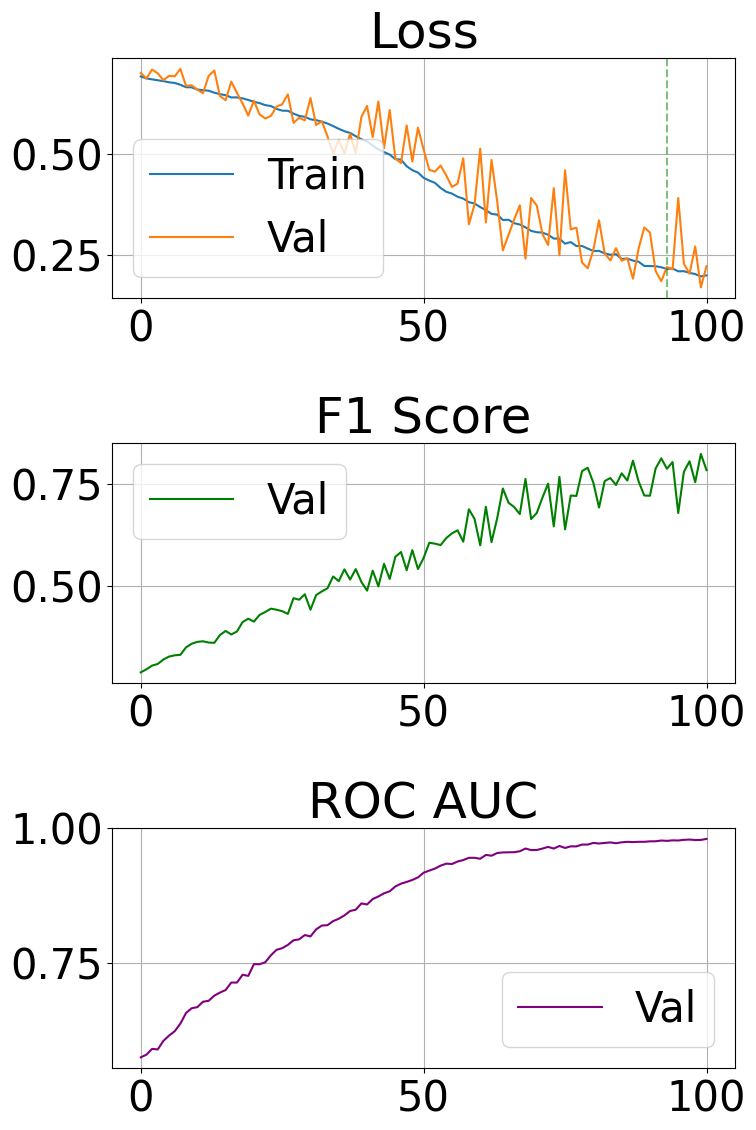


Загружены лучшие веса с эпохи 94 (лучший f1=0.8011)


In [ ]:
history = trainer.train(
    train_loader=train_loader_balanced,
    val_loader=val_loader,
    num_epochs=100
)

In [ ]:
# Сохраняем лучшие весы на Google Drive (если примонтирован)
SAVE_DIR = "/content/drive/MyDrive/team_model_weights"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_2.state_dict(), f"{SAVE_DIR}/model_crazy.pth")
print(f" Веса сохранены в {SAVE_DIR}/model_crazy.pth")

 Веса сохранены в /content/drive/MyDrive/team_model_weights/model_crazy.pth


In [ ]:
# Также сохраняем локально
torch.save(model_2.state_dict(), "model_crazy.pth")
print(" Веса сохранены локально как model_crazy.pth")

In [ ]:
print("\nметрики на валидац. выборке:")
print(f"Лучший val_loss: {min(trainer.history['val_loss']):.4f}")
print(f"Лучший val_f1: {max(trainer.history['val_f1']):.4f}")
print(f"Лучший val_auc: {max(trainer.history['val_auc']):.4f}")
print(f"Эпоха с лучшим loss: {trainer.history['val_loss'].index(min(trainer.history['val_loss'])) + 1}")


метрики на валидац. выборке:
Лучший val_loss: 0.1699
Лучший val_f1: 0.8234
Лучший val_auc: 0.9800
Эпоха с лучшим loss: 100


# Предсказания и submission

*тестовые данные*

In [ ]:
test_path = "/content/ml-intensive-yandex-academy-spring-2026/dataset/test_images/"

# Создаём тестовый датасет (без нормализации в transform)
test_dataset = KaggleTestDataset(test_path, transform=transform_no_norm)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print(f"ds {len(test_dataset)} изображений")

ds 10000 изображений


*предсказания*

In [ ]:
model_2.eval()
predictions = []
image_ids = []

# Сначала находим оптимальный порог на валидационной выборке
best_thresh = trainer.find_best_threshold(val_loader)

with torch.no_grad():
    for x, img_names in tqdm(test_loader, desc="Predicting"):
        x = x.to(device)
        outputs = model_2(x)
        # используем оптимальный порог вместо argmax
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs.cpu().numpy() > best_thresh).astype(int)
        predictions.extend(preds)
        image_ids.extend(img_names)

print(f"Сделано {len(predictions)} предсказаний")
print(f"Использован порог: {best_thresh:.2f}")
print(f"Распределение: REAL={predictions.count(0)}, FAKE={predictions.count(1)}")

Finding threshold: 100%|██████████| 157/157 [00:29<00:00,  5.37it/s]


Оптимальный порог: 0.88 (F1=0.8698)


Predicting: 100%|██████████| 157/157 [00:27<00:00,  5.79it/s]

Сделано 10000 предсказаний
Использован порог: 0.88
Распределение: REAL=8373, FAKE=1627


*Создание submission.csv*

In [ ]:
# Извлекаем ID из имён файлов (убираем .jpg)
submission = pd.DataFrame({
    'id': [os.path.splitext(name)[0] for name in image_ids],
    'Category': predictions
})

print("Первые 5 строк submission:")
print(submission.head())

print(f"\nРаспределение предсказаний:")
print(submission['Category'].value_counts())

# Сохраняем локально
submission.to_csv('submission.csv', index=False)
print(" сохранён локально")

# Сохраняем на Google Drive (если примонтирован)
try:
    submission.to_csv('/content/drive/MyDrive/submission.csv', index=False)
    print("сохранён на Google Drive")
except:
    print("на Google Drive не сохраненилось, только локально")

Первые 5 строк submission:
     id  Category
0  3104         1
1  3920         0
2  6035         0
3  4332         0
4  4618         0

Распределение предсказаний:
Category
0    8373
1    1627
Name: count, dtype: int64
 сохранён локально
сохранён на Google Drive


*Отправка на Kaggle (опционально)*

In [ ]:
# Отправляем результат на Kaggle
!kaggle competitions submit -c ml-intensive-yandex-academy-spring-2026 -f submission.csv -m "Experiment: model_2 with balanced sampler, lr=0.001, dropout=0.25, patience=5"


100% 67.3k/67.3k [00:01<00:00, 67.2kB/s]
Successfully submitted to ML intensive Yandex Academy spring 2026

*Скачивание submission локально*

In [ ]:
from google.colab import files
files.download('submission.csv')

*Визуализация*

In [ ]:
# Визуализируем несколько тестовых изображений с предсказаниями
plt.figure(figsize=(20, 8))

for i in range(10):
    img, _ = test_dataset[i]
    pred = predictions[i]
    label_text = "FAKE" if pred == 1 else "REAL"
    color = 'red' if pred == 1 else 'green'

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"{label_text}", color=color, fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Загрузка весов с диска, также смотрим их структуру и статистику
---

In [ ]:
import torch
import gdown


file_id = "1asGDsFGvFFCqnFpD_1wvZUiz33Ypnyww"
output = "model_crazy.pth"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

# Загружаем веса
weights = torch.load(output, map_location='cpu', weights_only=False)

Downloading...
From: https://drive.google.com/uc?id=1asGDsFGvFFCqnFpD_1wvZUiz33Ypnyww
To: /content/model_crazy.pth
100%|██████████| 1.71M/1.71M [00:00<00:00, 94.4MB/s]


*Структура*

In [ ]:
# Показываем структуру весов
print("Структура весов:")
for name, param in weights.items():
    print(f"{name:30s} | shape: {param.shape} | dtype: {param.dtype}")

Структура весов:
normalize.mean                 | shape: torch.Size([1, 3, 1, 1]) | dtype: torch.float32
normalize.std                  | shape: torch.Size([1, 3, 1, 1]) | dtype: torch.float32
block1.conv.weight             | shape: torch.Size([32, 3, 3, 3]) | dtype: torch.float32
block1.conv.bias               | shape: torch.Size([32]) | dtype: torch.float32
block1.bn.weight               | shape: torch.Size([32]) | dtype: torch.float32
block1.bn.bias                 | shape: torch.Size([32]) | dtype: torch.float32
block1.bn.running_mean         | shape: torch.Size([32]) | dtype: torch.float32
block1.bn.running_var          | shape: torch.Size([32]) | dtype: torch.float32
block1.bn.num_batches_tracked  | shape: torch.Size([]) | dtype: torch.int64
block2.conv.weight             | shape: torch.Size([64, 32, 3, 3]) | dtype: torch.float32
block2.conv.bias               | shape: torch.Size([64]) | dtype: torch.float32
block2.bn.weight               | shape: torch.Size([64]) | dtype: torch.

*Статистика*

In [ ]:
# Показываем статистику
print("\nСтатистика весов:")
for name, param in list(weights.items())[:5]:  # первые 5 слоев
    print(f"\n{name}:")
    print(f"  min: {param.min().item():.6f}")
    print(f"  max: {param.max().item():.6f}")
    print(f"  mean: {param.mean().item():.6f}")
    print(f"  std: {param.std().item():.6f}")


Статистика весов:

normalize.mean:
  min: 0.384537
  max: 0.520155
  mean: 0.444239
  std: 0.069248

normalize.std:
  min: 0.263855
  max: 0.285700
  mean: 0.271254
  std: 0.012512

block1.conv.weight:
  min: -1.111039
  max: 1.190422
  mean: -0.005569
  std: 0.289318

block1.conv.bias:
  min: -0.315603
  max: 0.364853
  mean: 0.001526
  std: 0.145288

block1.bn.weight:
  min: 0.526310
  max: 1.276003
  mean: 0.862778
  std: 0.187653
